This code is numpy specfic so that if I do not have access to GPU, atleast I possess a runnable code.

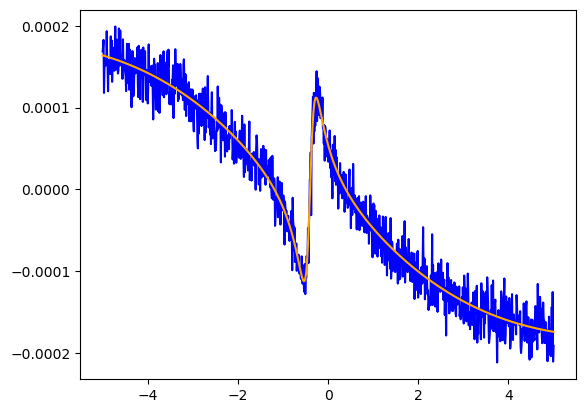

In [1]:
import numpy as np

# import cupy as cp
import matplotlib.pyplot as plt

global tou, delta, k2, transit_rate, lo

# spontaneous emission rate ~ 10^7 Hz
tou = 10**7
# detuning
delta = 0.1 * tou
# saturation parameter
k2 = 5
# transit rate
transit_rate = 0.01 * tou
# unsaturated absorption length
lo = 0.001


def alpha_th(B_tot):
    # gyromagnetic ratio ~ 10^6 Hz/Guass, larmor freq
    gyro = 1e6
    omega_l = gyro * (B_tot)
    D = (
        8
        * (omega_l**2)
        * (
            (32 * (tou**2) * (k2 + 3) * ((omega_l**2) + (delta**2)))
            + (192 * (((delta**2) - (omega_l**2)) ** 2))
            + ((tou**4) * (k2 + 2) * (k2 + 6))
        )
    ) + (
        2
        * (transit_rate**2)
        * (((tou**2) * ((2 * k2) + 3)) + (12 * (delta**2)))
        * (((tou**2) * ((k2 + 2) ** 2)) + (16 * (delta**2)))
    )
    alpha_th = (
        -6
        * tou
        * omega_l
        * (
            (
                8
                * (omega_l**2)
                * ((8 * (omega_l**2)) + ((tou**2) * (k2 + 2)) - (8 * (delta**2)))
            )
            + (
                transit_rate
                * (
                    (4 * transit_rate * ((tou**2) - ((2 * delta) ** 2)))
                    - ((tou**3) * k2 * (k2 + 2))
                )
            )
        )
        / D
    )
    return lo * alpha_th


def alpha_exp(alpha_th, sigma):
    return alpha_th + np.random.normal(0, sigma, size=alpha_th.shape)


B_unk = 0.4
gamma = 0.02
sigma = 2e-5

B_bias = np.linspace(-5, 5, 1000)
B_tot = B_unk + B_bias

alpha_vals = alpha_th(B_tot)


alpha_exp_vals = alpha_exp(alpha_vals, sigma)
plt.figure()
plt.plot(B_bias, alpha_exp_vals, color="blue")
plt.plot(B_bias, alpha_vals, color="orange")

In [8]:
from scipy.stats import norm
from scipy.integrate import simpson
import os

global tou, delta, k2, transit_rate, lo
# spontaneous emission rate
tou = 1
# detuning
delta = 0.1
# saturation parameter
k2 = 5
# transit rate
transit_rate = 0.01 * tou
# unsaturated absorption length
lo = 1


def alpha_theory(B_tot):
    return alpha_th(B_tot)


# Likelihood for a measurement
def likelihood(alpha_meas, B_unknown, B_bias, sigma=0.05, Gamma=1.0):
    B_total = B_unknown + B_bias
    alpha_exp = alpha_theory(B_total)
    return norm.pdf(alpha_meas, loc=alpha_exp, scale=sigma)


"""#likelihood  for cp and also actual expression
def likelihood(alpha_meas, B_unknown, B_bias, sigma=0.05):
    B_total = B_unknown + B_bias
    alpha_exp = alpha_theory(B_total)
    prefactor = 1.0 / (sigma * cp.sqrt(2 * np.pi))
    exponent = -((alpha_meas - alpha_exp)**2) / (2 * sigma**2)

    return prefactor * cp.exp(exponent)"""


def simpson_gpu(y, x):
    """Bro why is there no GPU implemetation of simpsons? :_("""
    dx = x[1] - x[0]
    n = len(x)
    if n % 2 == 0:
        x = x[:-1]
        y = y[..., :-1]

    # Simpson's 1/3 rule: dx/3 * (y_0 + 4y_1 + 2y_2 + ... + 4y_{n-1} + y_n)
    return (
        dx / 3.0 * cp.sum(y[..., 0:-1:2] + 4.0 * y[..., 1::2] + y[..., 2::2], axis=-1)
    )


# Posterior update
def update_posterior(prior, measurements, B_grid, B_bias, sigma=0.05):
    post = prior.copy()
    for alpha_meas in measurements:
        # FASTER: Calculate likelihood for all B_grid points at once
        L = likelihood(alpha_meas, B_grid, B_bias, sigma)
        post *= L

    # normalize
    post_sum = simpson(post, B_grid)
    if post_sum > 1e-12:
        post /= post_sum
    else:
        # Handle cases where the posterior is effectively zero everywhere
        post = np.ones_like(B_grid) / (B_grid.max() - B_grid.min())
    return post


# KL Divergence Utility
"""def expected_KL(B_bias, prior, B_grid, sigma=0.1, n_samples=100):
    # Sample possible outcomes (FIXME: this range is still hardcoded)
    alphas = np.linspace(-1.5, 1.5, n_samples)

    # Shape: (n_samples, n_grid)
    alpha_grid, B_grid_2d = np.meshgrid(alphas, B_grid, indexing='ij')
    L_matrix = likelihood(alpha_grid, B_grid_2d, B_bias, sigma)

    # Calculate marginal likelihood P(alpha|B_bias) for all alphas at once
    integrand_P_alpha = L_matrix * prior
    P_alpha = simpson(integrand_P_alpha, B_grid)
    norm_factors = P_alpha

    # To avoid division by zero for alphas with zero probability
    valid_indices = norm_factors>=0
    if not np.any(valid_indices):
        return 0.0

    post_matrix = integrand_P_alpha[valid_indices] / norm_factors[valid_indices, np.newaxis] #what does np.newaxis? FIXME

    ratio = post_matrix / (prior[np.newaxis, :] + 1e-12)
    KL_vals = simpson(post_matrix * np.log(ratio), B_grid)

    # Calculate the final expected value
    expected_KL_val = np.sum(P_alpha[valid_indices] * KL_vals) / np.sum(P_alpha[valid_indices])

    return float(expected_KL_val)"""


def expected_KL(B_bias, prior, B_grid, sigma=0.1, n_samples=100):
    # Sample possible outcomes (FIXME: this range is still hardcoded)
    alphas = np.linspace(-1.5, 1.5, n_samples)

    # Shape: (n_samples, n_grid)
    alpha_grid, B_grid_2d = np.meshgrid(alphas, B_grid, indexing="ij")
    L_matrix = likelihood(alpha_grid, B_grid_2d, B_bias, sigma)

    # Calculate marginal likelihood P(alpha|B_bias) for all alphas at once
    integrand_P_alpha = L_matrix * prior
    P_alpha = simpson(integrand_P_alpha, B_grid)
    norm_factors = P_alpha

    # To avoid division by zero for alphas with zero probability
    valid_indices = norm_factors > 1e-12  # Use a small epsilon
    if not np.any(valid_indices):
        return 0.0

    # Use a small epsilon for log(0)
    epsilon = 1e-20

    # Filter only valid alphas
    post_matrix = (
        integrand_P_alpha[valid_indices] / norm_factors[valid_indices, np.newaxis]
    )

    # Use np.log's 'where' argument to avoid log(0)
    ratio = post_matrix / (prior[np.newaxis, :] + epsilon)
    ratio[ratio <= 0] = epsilon
    log_ratio = np.log(ratio, where=ratio > 0, out=np.full_like(ratio, -np.inf))

    # Handle -inf * 0 cases
    KL_integrand = post_matrix * log_ratio
    KL_integrand[np.isnan(KL_integrand)] = 0.0

    KL_vals = simpson(KL_integrand, B_grid)

    # Calculate the final expected value
    P_alpha_valid = P_alpha[valid_indices]
    expected_KL_val = np.sum(P_alpha_valid * KL_vals) / np.sum(P_alpha_valid)

    return float(expected_KL_val)


# Adaptive Bayesian Experiment Loop
def run_experiment(
    N_exp=5,
    B_true=0.2,
    sigma=0.05,
    B_range=(-1, 1),
    n_grid=1000,
    candidates=np.linspace(-1, 1, 5000),
    Test=0,
    Gamma=1.0,
):  # FIXME: Why is b_range (-1,1)?
    # Step 1: initialize prior
    B_grid = np.linspace(B_range[0], B_range[1], n_grid)
    prior = np.ones_like(B_grid) / (B_range[1] - B_range[0])  # uniform prior
    B_biases = []
    Expected_KL = []
    posteriors = [prior]

    for _ in range(N_exp):
        # Step 2: choose bias by maximizing expected KL # FIXME
        # FIXME range of candidates is arbitrary
        util_vals = np.array([expected_KL(b, prior, B_grid, sigma) for b in candidates])
        B_bias = candidates[np.argmax(util_vals)]
        B_biases.append(B_bias)
        Expected_KL.append(float(util_vals[np.argmax(util_vals)]))

        # code block which creates and saves plots of expected KL vs B_bias for each experiment within directory "Experiment i" - need to do the np to np conversion
        # to use matplotlib ig - FIXME
        # new_dir = "/content/drive/MyDrive/Colab_Notebooks/UGP_2/Test_{Test}".format(Test=Test)
        # os.makedirs(new_dir, exist_ok=True)
        # save_path = os.path.join(new_dir, f'Expected_KL_vs_B_bias_Experment{_+1}.png')
        plt.figure(figsize=(6, 4))
        plt.plot(
            candidates,
            util_vals,
            label="Expected KL divergence as a function of B_Bias",
        )
        plt.xlabel("B_bias")
        plt.ylabel("Expected KL Divergence")
        plt.title("Expected KL vs B_bias for Experiment {i}".format(i=_ + 1))
        # plt.savefig(save_path)

        # Step 3: generate synthetic measurement
        B_total = B_true + B_bias
        alpha_true = alpha_theory(B_total)
        alpha_meas = np.random.normal(
            alpha_true, sigma, size=5
        )  # 5 samples -> Integration time FIXME
        # Step 4: update posterior
        posterior = update_posterior(prior, alpha_meas, B_grid, B_bias, sigma)
        posteriors.append(posterior)
        prior = posterior
    final_posteriors_cpu = [p for p in posteriors]
    final_biases_cpu = B_biases  # .get()
    final_B_grid = B_grid

    return final_B_grid, final_posteriors_cpu, final_biases_cpu, Expected_KL


def calculate_summary_stats(posterior, B_grid):
    # Mean
    mean = simpson(B_grid * posterior, B_grid)

    # Mode
    mode_index = np.argmax(posterior)
    mode = B_grid[mode_index]

    # Variance
    variance = simpson(((B_grid - mean) ** 2) * posterior, B_grid)

    return mean, mode, variance

Test 0

In [ ]:
# @title
# Run adaptive Bayesian experiment from module
import matplotlib.pyplot as plt

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=10,
    B_true=B_true,
    Gamma=1.0,
    sigma=2e-5,
    B_range=(-5, 5),
    n_grid=10000,
    candidates=np.linspace(-5, 5, 10000),
    Test=0,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

Test 1

Final posterior area (should be ~1): 1.000000


C:\Users\Admin\AppData\Local\Temp\ipykernel_18600\4170681887.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


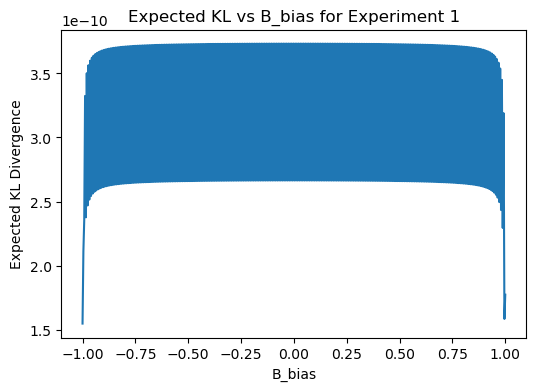

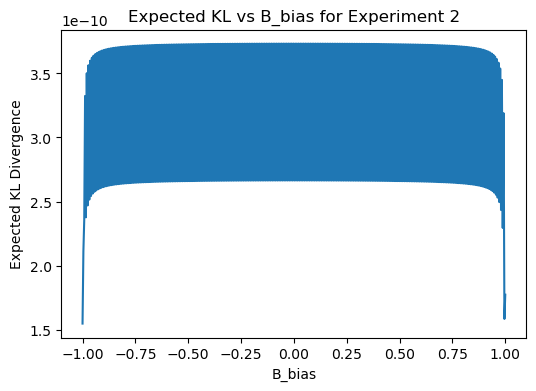

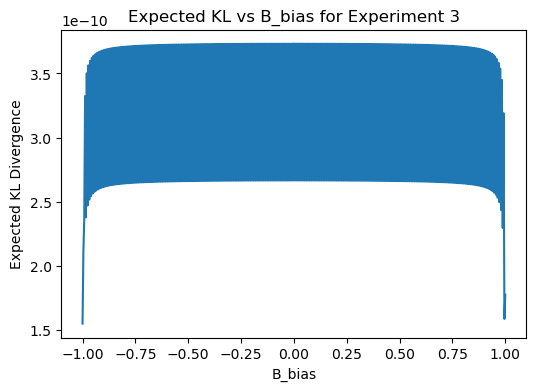

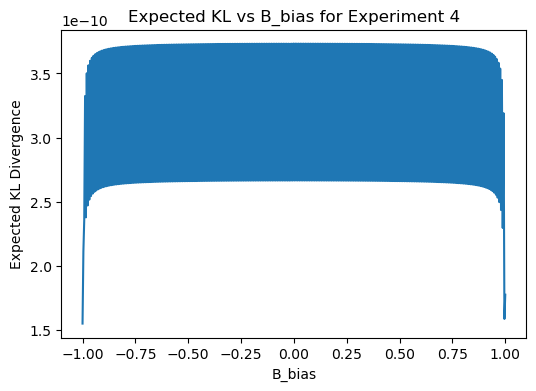

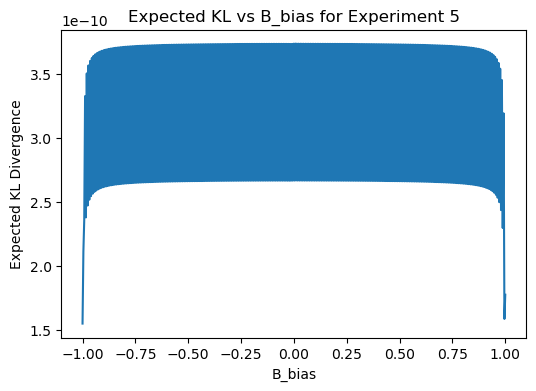

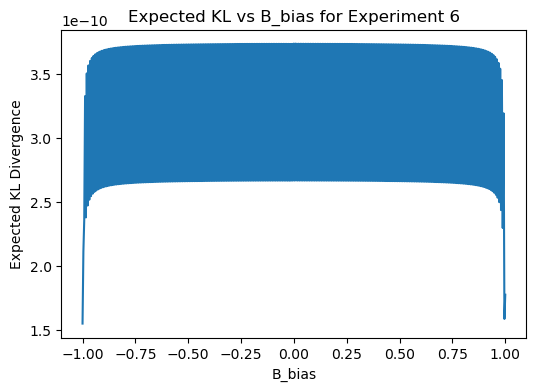

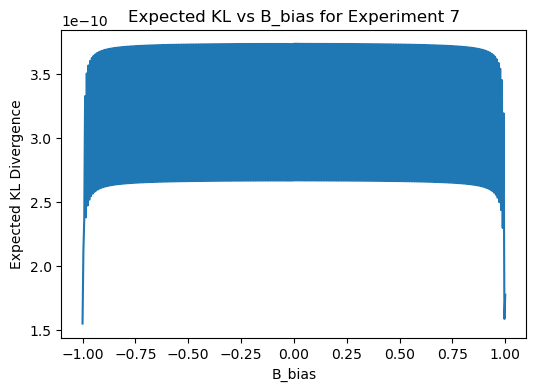

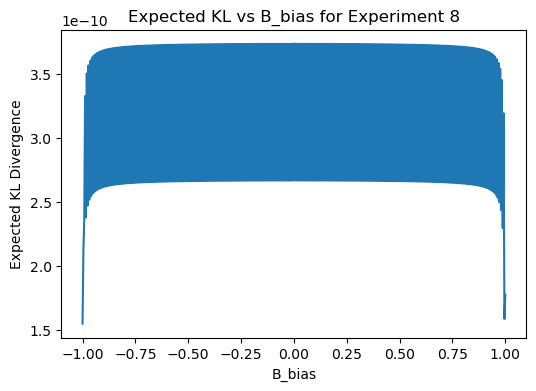

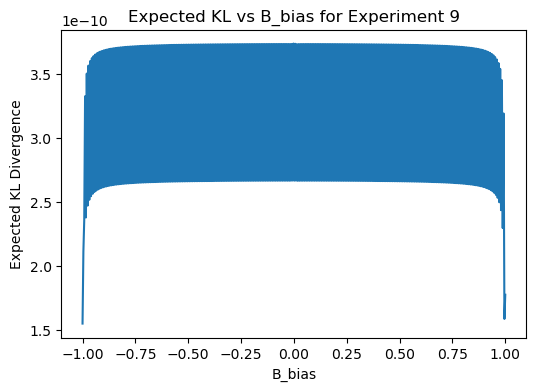

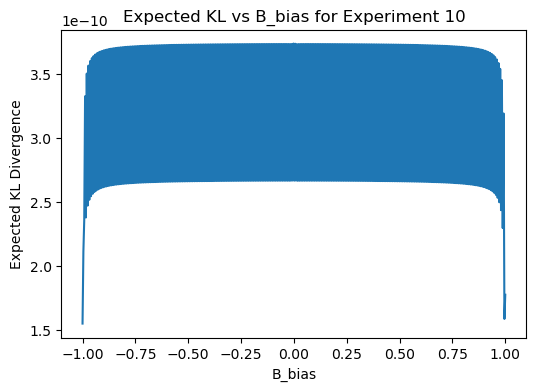

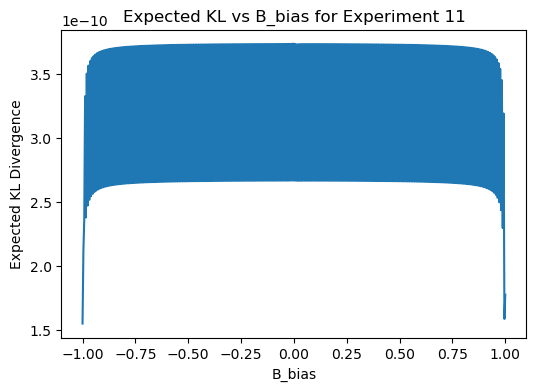

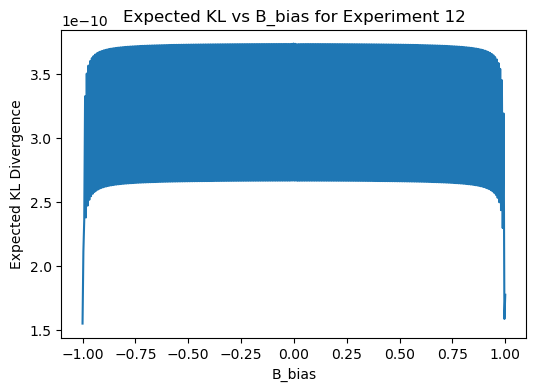

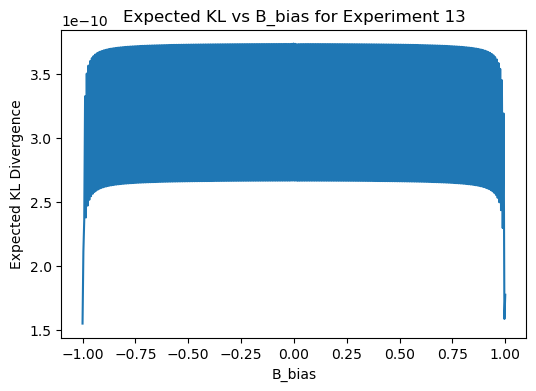

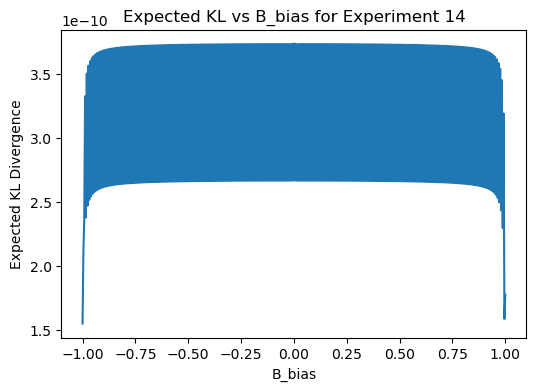

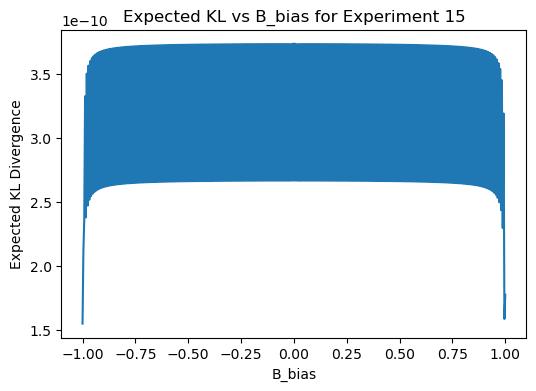

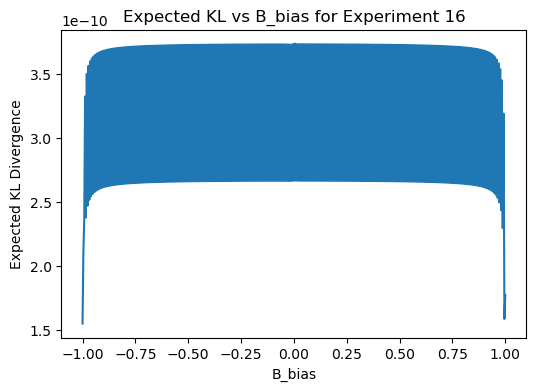

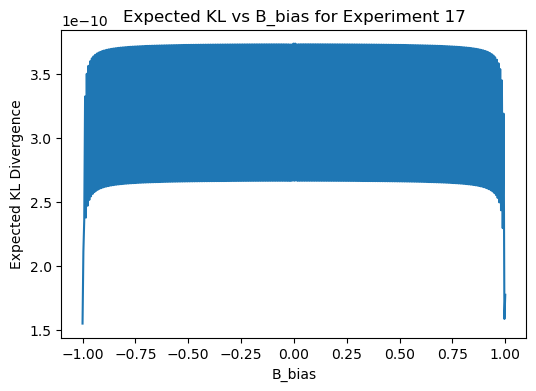

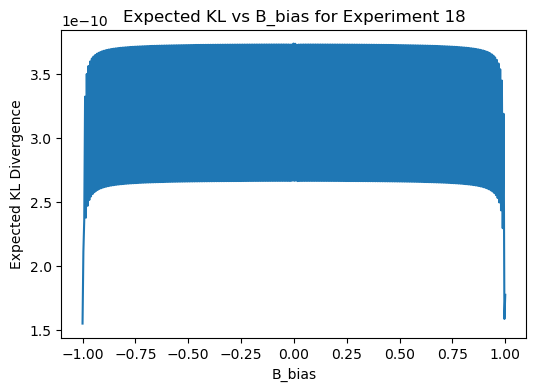

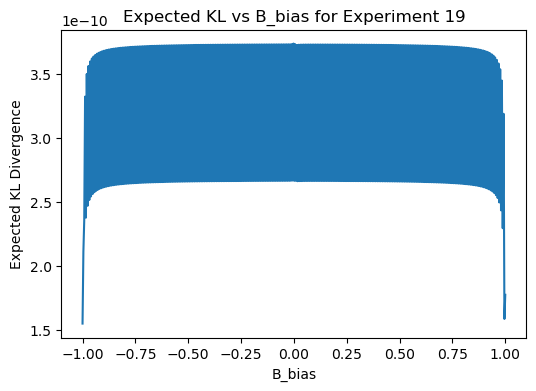

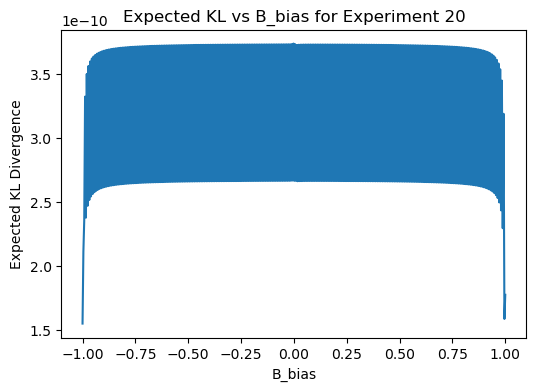

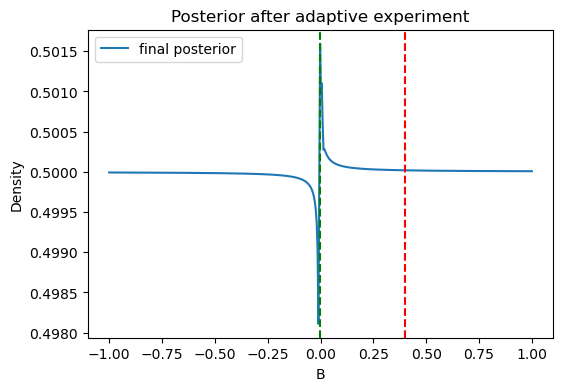

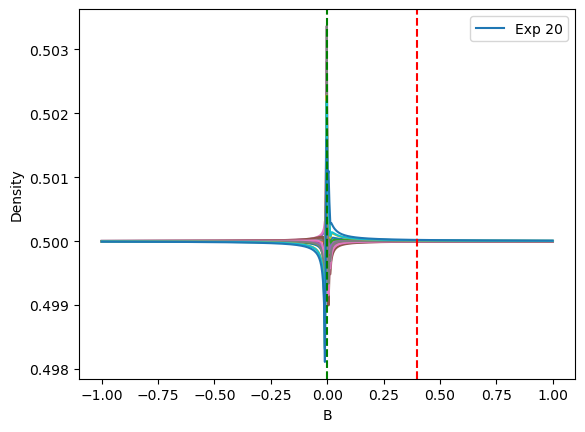

Mean: 1.552898544754204e-05 , Mode: -0.002004008016032177 , Varianc: 0.33333319606531797
-0.002004008016032177 : 3.73291233745247e-10 

-0.010020040080160442 : 3.733016072628136e-10 

-0.002004008016032177 : 3.733529516322663e-10 

-0.002004008016032177 : 3.733529064701912e-10 

0.006012024048096087 : 3.734623593986741e-10 

0.006012024048096087 : 3.7346242252974697e-10 

0.006012024048096087 : 3.7346228823117273e-10 

0.006012024048096087 : 3.7346228437059255e-10 

-0.002004008016032177 : 3.7361587160739236e-10 

-0.002004008016032177 : 3.736158651745025e-10 

-0.002004008016032177 : 3.736155025858901e-10 

-0.002004008016032177 : 3.7361554974091083e-10 

-0.002004008016032177 : 3.736156223609863e-10 

-0.002004008016032177 : 3.7361570980654263e-10 

-0.002004008016032177 : 3.736156370225354e-10 

0.006012024048096087 : 3.7380268042301943e-10 

0.006012024048096087 : 3.7380330030927824e-10 

-0.002004008016032177 : 3.739507072804105e-10 

-0.002004008016032177 : 3.7394908171403385e-10

In [6]:
B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=20,
    B_true=B_true,
    sigma=0.2,
    B_range=(-1, 1),
    n_grid=500,
    candidates=np.linspace(-1, 1, 500),
    Test=1,
    Gamma=0.1,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

Test 3

KeyboardInterrupt: 

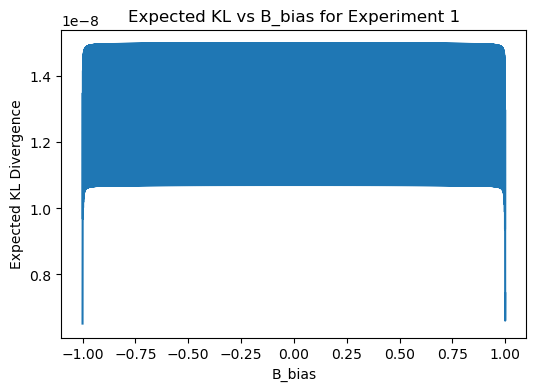

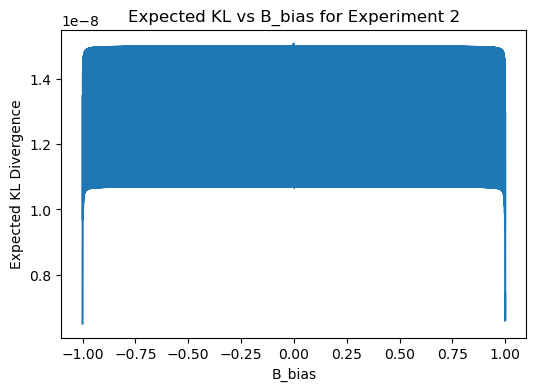

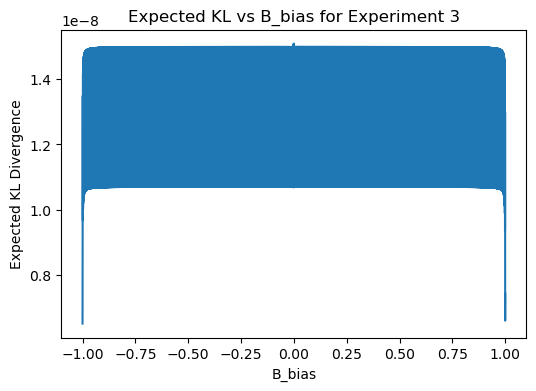

In [5]:
B_true = 0.4
B_grid, posteriors, biases = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0.1,
    B_range=(-1, 1),
    n_grid=5000,
    candidates=np.linspace(-1, 1, 5000),
    Test=3,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for b in biases:
    print(b, "\n")

Test 4

In [ ]:
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0.1,
    B_range=(-1, 1),
    n_grid=500,
    candidates=np.linspace(-1, 1, 500),
    Test=4,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

Test 5

In [ ]:
B_true = 0.4
B_grid, posteriors, biases = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0.05,
    B_range=(-1, 1),
    n_grid=5000,
    candidates=np.linspace(-1, 1, 5000),
    Test=5,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for b in biases:
    print(b, "\n")

  Test 6

In [ ]:
B_true = 0.4
B_grid, posteriors, biases = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0.05,
    B_range=(-1, 1),
    n_grid=500,
    candidates=np.linspace(-1, 1, 500),
    Test=6,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for b in biases:
    print(b, "\n")

In [ ]:
# TODO: Parallelise
# TODO: compare with frequentist zero crossing approach: give quantitative estimate of:
# 1. amount of readings required for both
# 2. accuracy of estimate for both
# 3. inference time for both